# 5. Superdense Coding

Superdense coding lets Alice send **2 classical bits** of information
by physically sending Bob only **1 qubit** — using a pair of qubits
they shared and entangled ahead of time.

The protocol:
1. Alice and Bob share an entangled pair (a Bell pair).
2. Alice encodes 2 classical bits onto her qubit using I, X, Z, or
   both X and Z.
3. Alice sends her single qubit to Bob.
4. Bob applies CNOT + H and measures both qubits to recover the
   original 2 bits.

## Step 1: Import libraries

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_distribution, plot_histogram

simulator = AerSimulator()

## Step 2: Create the shared entangled pair (Bell pair)

Qubit 0 = Alice's qubit, Qubit 1 = Bob's qubit.

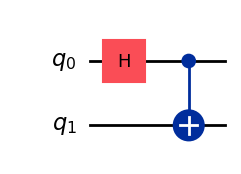

In [2]:
qc_shared = QuantumCircuit(2)
qc_shared.h(0)
qc_shared.cx(0, 1)
qc_shared.draw("mpl")

Shared Bell pair probabilities: {np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


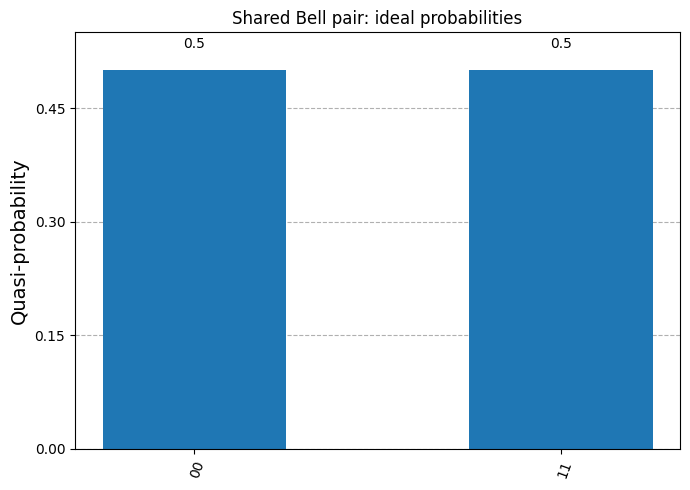

In [3]:
probs_shared = Statevector(qc_shared).probabilities_dict()
print("Shared Bell pair probabilities:", probs_shared)
plot_distribution(probs_shared, title="Shared Bell pair: ideal probabilities")

## Message "00": Alice does nothing (identity)

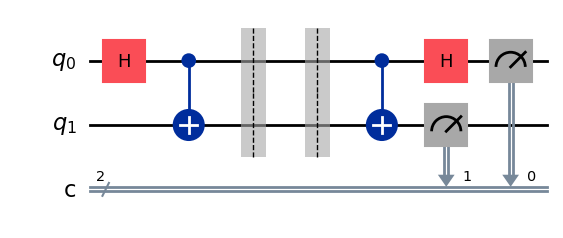

In [4]:
qc_00 = QuantumCircuit(2, 2)
qc_00.h(0)
qc_00.cx(0, 1)
qc_00.barrier()
# Alice's encoding step: nothing to do for "00"
qc_00.barrier()
qc_00.cx(0, 1)   # Bob decodes
qc_00.h(0)
qc_00.measure([0, 1], [0, 1])
qc_00.draw("mpl")

Sent '00' -> Bob measured: {'00': 1024}


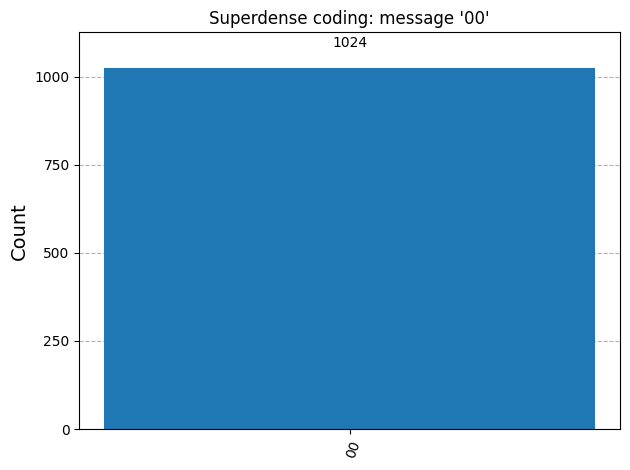

In [5]:
counts_00 = simulator.run(transpile(qc_00, simulator), shots=1024).result().get_counts()
print("Sent '00' -> Bob measured:", counts_00)
plot_histogram(counts_00, title="Superdense coding: message '00'")

## Message "01": Alice applies X

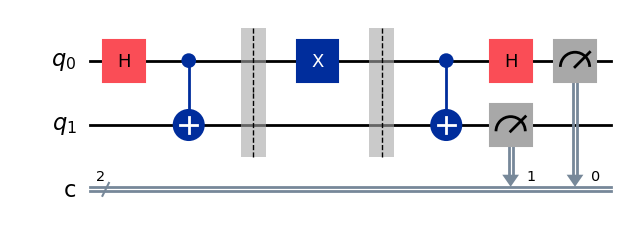

In [6]:
qc_01 = QuantumCircuit(2, 2)
qc_01.h(0)
qc_01.cx(0, 1)
qc_01.barrier()
qc_01.x(0)       # Alice's encoding step for "01"
qc_01.barrier()
qc_01.cx(0, 1)   # Bob decodes
qc_01.h(0)
qc_01.measure([0, 1], [0, 1])
qc_01.draw("mpl")

Sent '01' -> Bob measured: {'10': 1024}


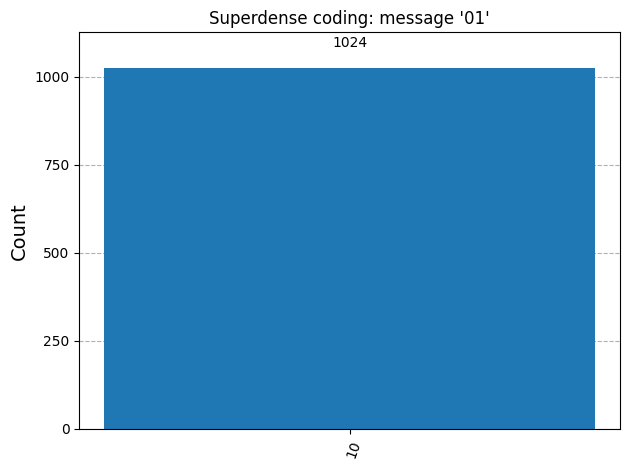

In [7]:
counts_01 = simulator.run(transpile(qc_01, simulator), shots=1024).result().get_counts()
print("Sent '01' -> Bob measured:", counts_01)
plot_histogram(counts_01, title="Superdense coding: message '01'")

## Message "10": Alice applies Z

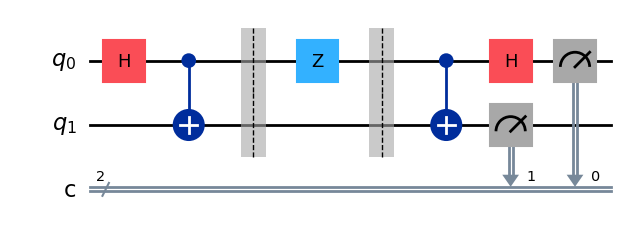

In [8]:
qc_10 = QuantumCircuit(2, 2)
qc_10.h(0)
qc_10.cx(0, 1)
qc_10.barrier()
qc_10.z(0)       # Alice's encoding step for "10"
qc_10.barrier()
qc_10.cx(0, 1)   # Bob decodes
qc_10.h(0)
qc_10.measure([0, 1], [0, 1])
qc_10.draw("mpl")

Sent '10' -> Bob measured: {'01': 1024}


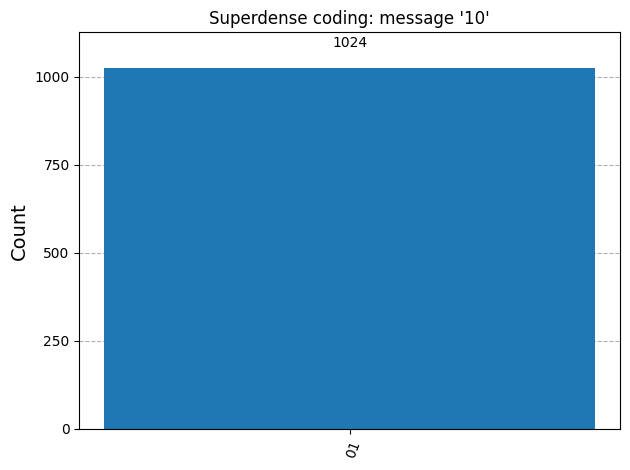

In [9]:
counts_10 = simulator.run(transpile(qc_10, simulator), shots=1024).result().get_counts()
print("Sent '10' -> Bob measured:", counts_10)
plot_histogram(counts_10, title="Superdense coding: message '10'")

## Message "11": Alice applies Z then X

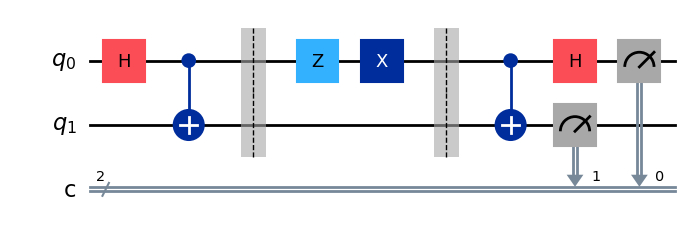

In [10]:
qc_11 = QuantumCircuit(2, 2)
qc_11.h(0)
qc_11.cx(0, 1)
qc_11.barrier()
qc_11.z(0)       # Alice's encoding step for "11"
qc_11.x(0)
qc_11.barrier()
qc_11.cx(0, 1)   # Bob decodes
qc_11.h(0)
qc_11.measure([0, 1], [0, 1])
qc_11.draw("mpl")

Sent '11' -> Bob measured: {'11': 1024}


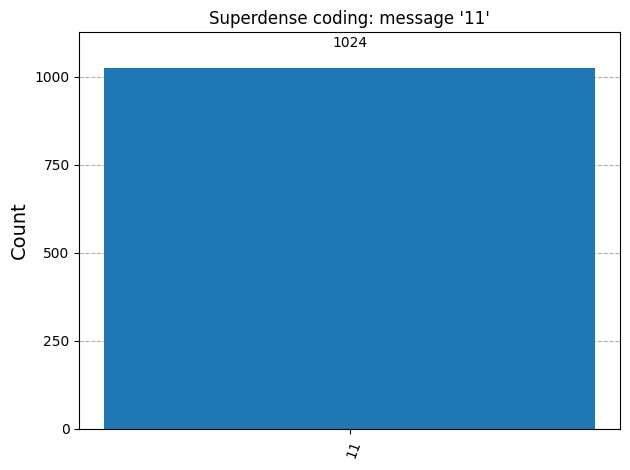

In [11]:
counts_11 = simulator.run(transpile(qc_11, simulator), shots=1024).result().get_counts()
print("Sent '11' -> Bob measured:", counts_11)
plot_histogram(counts_11, title="Superdense coding: message '11'")

## Summary

Note: Qiskit prints classical bits in reverse order (`c1 c0`), so
the count key you see is the message reversed. For every message
above, Bob's measurement matches the bits Alice sent — she
transmitted 2 classical bits by physically sending only 1 qubit.